# Section B - Diabetes Prediction System

Technovate Practical Round

A healthcare startup wants to spot patients at high risk of diabetes early.
This notebook builds and evaluates that classifier.

**Dataset:** PIMA Diabetes - 768 patients, 8 measurements, 1 outcome (1 = diabetic).
Sourced from [Kaggle](https://www.kaggle.com/datasets/kumargh/pimaindiansdiabetescsv) (CC0 Public Domain).

**Model:** Logistic Regression. The reasoning is at the end, after the results.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
)

## 1. Load the data

In [2]:
df = pd.read_csv("diabetes.csv")

print("Shape:", df.shape)
df.head()

Shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
# 500 non-diabetic vs 268 diabetic - the classes are uneven, which matters later
df["Outcome"].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

## 2. Preprocess

### The zero problem

In this dataset a `0` means **"not recorded"**, not an actual measurement.
A patient cannot have a BMI of 0 or a blood pressure of 0. Those are gaps.

If we leave them in, the model learns from impossible values.

In [4]:
zero_is_missing = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

# Count how many gaps are hiding as zeros
(df[zero_is_missing] == 0).sum()

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

In [5]:
# Turn those zeros into proper "missing" markers so they can be filled later
df[zero_is_missing] = df[zero_is_missing].replace(0, np.nan)

## 3. Split into train and test

The test set stands in for patients the model has never seen.
`stratify=y` keeps the same diabetic / non-diabetic ratio in both halves.

In [6]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape[0], "patients")
print("Test :", X_test.shape[0], "patients")

Train: 614 patients
Test : 154 patients


### Filling the gaps

Each gap is filled with the column's **median** (the middle value), which is less
distorted by extreme readings than the average.

The median is calculated from the **training set only**. If it came from the whole
dataset, the test patients would have helped shape the training data, and the test
score would flatter the model. Splitting first keeps the test set genuinely unseen.

In [7]:
medians = X_train.median()

X_train = X_train.fillna(medians)
X_test = X_test.fillna(medians)

print("Remaining gaps:", X_train.isna().sum().sum() + X_test.isna().sum().sum())

Remaining gaps:

 0


## 4. Scale the features

Logistic Regression weighs features against each other directly. Insulin runs into
the hundreds while BMI sits around 30, so without scaling Insulin would dominate
purely because its numbers are bigger.

Scaling puts every column on the same footing. The scaler is fitted on the training
set and then applied to the test set, for the same reason as the medians above.

In [8]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## 5. Train the model

`class_weight="balanced"` matters here. Only 35% of patients are diabetic, so a
model chasing raw accuracy learns to guess "not diabetic" and still looks decent.
This setting tells it to treat the smaller diabetic group as equally important,
so fewer real cases get missed - which is the whole point of a screening tool.

In [9]:
model = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

# [:, 1] picks the probability of diabetes rather than of no diabetes
y_prob = model.predict_proba(X_test_scaled)[:, 1]

## 6. Evaluate

In [10]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[75 25]
 [16 38]]


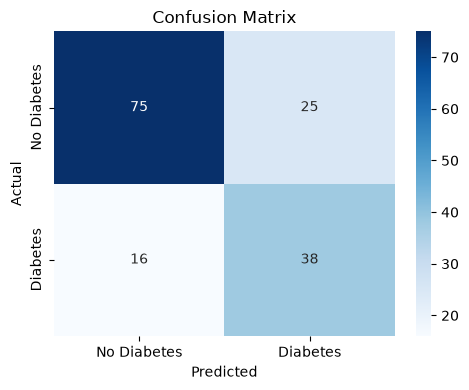

In [11]:
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Diabetes", "Diabetes"],
            yticklabels=["No Diabetes", "Diabetes"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.show()

Reading the matrix:

| | meaning |
|---|---|
| top-left | healthy patients correctly cleared |
| top-right | healthy patients wrongly flagged - a false alarm, they get a follow-up test |
| bottom-left | **diabetic patients missed** - the costly error |
| bottom-right | diabetic patients correctly caught |

In [12]:
print(classification_report(y_test, y_pred, target_names=["No Diabetes", "Diabetes"]))
print("ROC AUC:", round(roc_auc_score(y_test, y_prob), 3))

              precision    recall  f1-score   support

 No Diabetes       0.82      0.75      0.79       100
    Diabetes       0.60      0.70      0.65        54

    accuracy                           0.73       154
   macro avg       0.71      0.73      0.72       154
weighted avg       0.75      0.73      0.74       154

ROC AUC: 0.813


For a screening tool, **recall on the Diabetes row is the number that matters** -
it is the share of genuinely diabetic patients the model catches. A missed case is
far worse than a false alarm, since a false alarm only costs one extra test.

## 7. Choosing the cut-off

The model never says "yes" or "no". It gives a **risk score** - a number between
0% and 100%.

Someone still has to decide where the line goes. Right now the line is at **50%**:
above 50%, flag the patient. Below 50%, let them go.

That 50% is a choice we made. We could have picked any number. The table below
shows what happens when we do.

In [13]:
# Count what happens at different cut-offs
print("cut-off   caught   missed   false alarms")

for t in [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]:
    flagged = (y_prob >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, flagged).ravel()
    print("  %.0f%%      %2d/54     %2d       %2d/100" % (t * 100, tp, fn, fp))

cut-off   caught   missed   false alarms
  30%      48/54      6       40/100
  40%      45/54      9       34/100
  50%      38/54     16       25/100
  60%      31/54     23       21/100
  70%      26/54     28       16/100
  80%      23/54     31        9/100


### What the table says

There are two kinds of mistake:

- **Missed** - the patient has diabetes, but we let them go home.
- **False alarm** - the patient is healthy, but we flag them anyway.

Look at those two columns. **When one goes down, the other goes up. Always.**

- Set the line at **30%**: we catch 48 of 54 diabetics. Great. But we flag 40 out of
  100 healthy patients - nearly half of them.
- Set it at **80%**: false alarms drop to just 9. Also great. But now we miss 31
  diabetics instead of 16 - twice as many.

So there is no perfect setting. **Moving the line doesn't get rid of mistakes.
It just decides who we make mistakes about.**

### So why 50%?

Because the two mistakes don't hurt the same amount.

| mistake | what happens to that person |
|---|---|
| False alarm | takes one extra blood test, finds out they're fine |
| Missed case | goes home not knowing they're diabetic, gets worse over time |

A missed case is clearly worse. So we want the model to lean towards flagging
people rather than clearing them.

That is what `class_weight="balanced"` does in step 5. Without it the model catches
only 27 of 54 diabetics. With it, 38.

**50% keeps that lean without going too far.** We could drop to 30% and catch 10 more
diabetics - but then 40 out of every 100 healthy patients get flagged. If a tool cries
wolf that often, doctors stop paying attention to it, and then it helps nobody.

### False alarms still cost something

It would be wrong to call false alarms harmless. Right now **25 out of 100 healthy
patients get flagged**. That means:

- an extra appointment and blood test they didn't need
- money and time for both them and the clinic
- being told you might have diabetes is frightening, even if you're later cleared

We accept that cost because a missed diabetic is worse - not because it's free.

Also worth saying: this tool is a **screening tool, not a diagnosis**. Being flagged
just means "go get the proper test". Nobody is treated based on this model alone.

And the right number isn't really ours to pick. It depends on how much a follow-up
test costs the clinic and how many patients they can handle. Our job is to give an
honest risk score and show clearly what each choice costs.

### What would actually make this better

Moving the line just shuffles mistakes around. To make **fewer** mistakes overall,
the model needs better information:

- **More measurements.** Eight is not many. Family history, diet, exercise and HbA1c
  would all help.
- **Better data.** Insulin is missing for 374 of the 768 patients - almost half. We
  filled all those gaps with one single number, which is why Insulin ends up with
  almost no importance in the chart above. Fixing that would help far more than any
  amount of tweaking the model.

## 8. ROC curve

Shows the trade-off between catching real cases and raising false alarms.
The dashed line is random guessing; the further the curve sits above it, the better.
AUC is the area underneath - 1.0 is perfect, 0.5 is a coin flip.

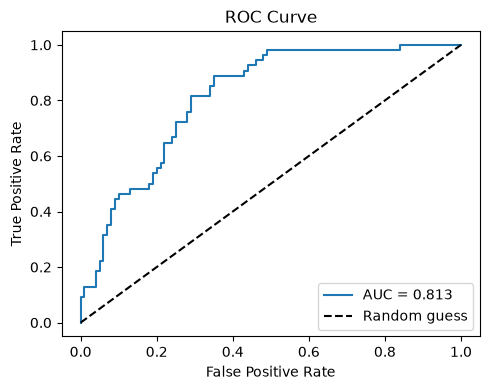

In [14]:
fpr, tpr, _ = roc_curve(y_test, y_prob)

plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, label="AUC = %.3f" % roc_auc_score(y_test, y_prob))
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

## 9. Feature importance

Each coefficient shows how strongly a feature pushes a prediction toward diabetes.
Bigger positive bar means stronger push.

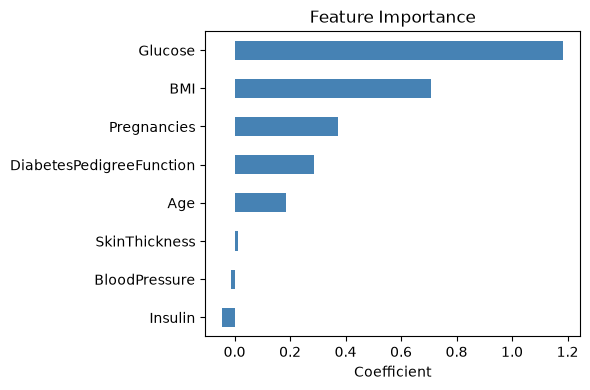

Glucose                     1.183483
BMI                         0.709592
Pregnancies                 0.372902
DiabetesPedigreeFunction    0.287734
Age                         0.186434
SkinThickness               0.013980
BloodPressure              -0.014612
Insulin                    -0.044609
dtype: float64

In [15]:
importance = pd.Series(model.coef_[0], index=X.columns).sort_values()

plt.figure(figsize=(6, 4))
importance.plot(kind="barh", color="steelblue")
plt.xlabel("Coefficient")
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

importance.sort_values(ascending=False)

Glucose dominates by a wide margin, then BMI. That matches medical expectation,
which is a good sign the model learned something real rather than noise.

## 10. Sample predictions

Three test patients, shown as input measurements followed by the model's verdict.

These three were picked on purpose so all three outcomes are visible: a diabetic
patient the model **caught**, a healthy patient it **correctly cleared**, and a
diabetic patient it **missed**. Simply taking the first three would have shown no
diabetic patients at all, since two out of three patients in this dataset are healthy.

In [16]:
# patients 7, 4 and 3: one caught, one cleared, one missed
for i in [7, 4, 3]:
    patient = X_test.iloc[i]
    prediction = "Diabetes" if y_pred[i] == 1 else "No Diabetes"
    actual = "Diabetes" if y_test.iloc[i] == 1 else "No Diabetes"

    print("Patient", i)
    print("  Input :")

    # print each measurement on its own line
    for name, value in patient.items():
        print("    %s = %g" % (name, value))

    print("  Output:", prediction, "(risk %.1f%%)" % (y_prob[i] * 100))
    print("  Actual:", actual)
    print()

Patient 7
  Input :
    Pregnancies = 8
    Glucose = 197
    BloodPressure = 74
    SkinThickness = 29
    Insulin = 125
    BMI = 25.9
    DiabetesPedigreeFunction = 1.191
    Age = 39
  Output: Diabetes (risk 96.2%)
  Actual: Diabetes

Patient 4
  Input :
    Pregnancies = 2
    Glucose = 74
    BloodPressure = 72
    SkinThickness = 29
    Insulin = 125
    BMI = 32.4
    DiabetesPedigreeFunction = 0.102
    Age = 22
  Output: No Diabetes (risk 5.5%)
  Actual: No Diabetes

Patient 3
  Input :
    Pregnancies = 7
    Glucose = 114
    BloodPressure = 64
    SkinThickness = 29
    Insulin = 125
    BMI = 27.4
    DiabetesPedigreeFunction = 0.732
    Age = 34
  Output: No Diabetes (risk 38.3%)
  Actual: Diabetes



**Note:** all three patients show `Insulin = 125` and `SkinThickness = 29`. Those are
not real readings - they are the median values we filled in back in step 3, because
all three patients were missing both measurements. That is not a coincidence: Insulin
is missing for 374 of 768 patients and SkinThickness for 227, so most patients end up
with the same filled-in number. It is a good reminder of how much of that data is
actually guessed.

## 11. Why Logistic Regression

We did not just pick one. Three models were trained and compared first.

The score below is **AUC** - how well a model separates diabetic from non-diabetic
patients. 1.0 is perfect, 0.5 is a coin flip. Higher is better, and a smaller
+/- means the model behaves more consistently.

In [17]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from xgboost import XGBClassifier

# Prepare one clean copy of the full dataset for cross-validation
X_all = X.fillna(X_train.median())
cv = StratifiedKFold(5, shuffle=True, random_state=42)

candidates = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42,
                                              class_weight="balanced"),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42,
                                            class_weight="balanced"),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=3, random_state=42,
                             scale_pos_weight=(y == 0).sum() / (y == 1).sum(),
                             eval_metric="logloss"),
}

for name, candidate in candidates.items():
    scores = cross_val_score(candidate, StandardScaler().fit_transform(X_all), y,
                             cv=cv, scoring="roc_auc")
    print("%-20s cross-validated AUC: %.3f (+/- %.3f)" % (name, scores.mean(), scores.std()))

Logistic Regression  cross-validated AUC: 0.836 (+/- 0.020)


Random Forest        cross-validated AUC: 0.828 (+/- 0.019)


XGBoost              cross-validated AUC: 0.800 (+/- 0.032)


### Why Logistic Regression won

**1. It scored best when tested properly.**

On our single test split, XGBoost actually looked best. But our test set is only 154
patients, so a 2-3% difference is just three or four people landing on the other side
of the line. That is luck, not skill.

Cross-validation is the fairer test - it splits the data five different ways and takes
the average. On that test, Logistic Regression came out on top (0.836), and its scores
also varied the least. So it is the most reliable of the three.

**2. It can explain its answers.**

This is the big one for a medical tool.

Logistic Regression gives a number for each measurement showing how much it mattered -
Glucose 1.18, BMI 0.71, and so on. A doctor can look at a flagged patient and see
*why*: her glucose was high.

XGBoost just gives a risk score with no reasoning. In a hospital, "the computer said
so" is not an answer anyone can act on.

**3. Its risk scores are trustworthy.**

When it says 73%, that genuinely means roughly 73 out of 100 similar patients would be
diabetic. That lets a clinic rank patients by risk and move the cut-off, as in step 7.

**4. It is the simplest option.**

Nothing to tune, trains instantly, and anyone can read the code. With only 768 patients
and 8 measurements, a more complex model has nothing extra to learn from.

### What this model cannot do

Being straight about the weak points:

- **It misses about 3 in 10 diabetic patients.** That is fine for a first check that
  sends people for a proper test. It is not a diagnosis.
- **Insulin data is mostly missing** - 374 of 768 patients. We filled those gaps with
  one number, which is why Insulin barely registers in the importance chart. That
  measurement is effectively wasted.
- **Everyone in this data is a woman aged 21 or over.** We cannot assume the model
  works on men or younger patients without testing it on them first.